# Milton: OLS Regression Results

**Objective**: Test whether socioeconomic features predict hurricane disruption metrics.

**DVs**: Largest drop (within), Recovery time (within), Outflow increase, Total disruption

**Models**:
- M1: Income + Vehicle + Insurance (original)
- M2: M1 + Race + Urban-Rural (no education — collinear with income at r=0.97)
- M3: M2 + Distance to track

**Notes**:
- `pct_bachelors_plus` excluded from multivariate models (r=0.97 with income)
- Shown in bivariate analysis separately
- N = 21 counties

In [1]:
import pandas as pd
import numpy as np
import os
import warnings

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr, pearsonr

warnings.filterwarnings('ignore')

OUTPUT_DIR = '../results/ols_results_milton/'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, 'figures'), exist_ok=True)
print('Setup complete.')

Setup complete.


## 1. Load Data

In [2]:
results_dir = '../results/milton/'
drop_df = pd.read_csv(os.path.join(results_dir, 'largest_drop_within.csv'))
recovery_df = pd.read_csv(os.path.join(results_dir, 'recovery_within.csv'))
outflow_df = pd.read_csv(os.path.join(results_dir, 'outflow_increase.csv'))
acs_df = pd.read_csv('acs_socioeconomic_v2.csv')
geo_idx = pd.read_csv('geoid_idx_names.csv')
dist_df = pd.read_csv('../results/spatial_diagnostics_milton/county_distance_to_track.csv')
nchs = pd.read_csv('../data/NCHS Urban-Rural Classification Scheme for Counties.csv', encoding='utf-8-sig')

for d in [drop_df, recovery_df, outflow_df, acs_df, geo_idx, dist_df]:
    d['GEOID'] = d['GEOID'].astype(int)

nchs['GEOID'] = nchs['Location'].astype(int)
nchs['nchs_code'] = nchs['2023 Code'].str.extract(r'(\d)').astype(int)

df = drop_df[['GEOID', 'largest_drop']].merge(
    recovery_df[['GEOID', 'recovery_days']], on='GEOID', how='outer'
).merge(
    outflow_df[['GEOID', 'largest_increase']], on='GEOID', how='outer'
).merge(
    acs_df[['GEOID', 'total_population', 'median_household_income',
            'pct_no_vehicle', 'insurance_coverage_pct',
            'pct_bachelors_plus', 'pct_white']], on='GEOID'
).merge(
    geo_idx[['GEOID', 'NAME']], on='GEOID'
).merge(
    dist_df[['GEOID', 'dist_to_track_mi']], on='GEOID'
).merge(
    nchs[['GEOID', 'nchs_code']], on='GEOID', how='left'
)

df['is_nonmetro'] = (df['nchs_code'] >= 4).astype(int)
df['abs_drop'] = df['largest_drop'].abs()
df['total_disruption'] = df['recovery_days'] * df['abs_drop']

print(f'N = {len(df)} counties')
print(f'\nCounty data:')
display(df[['NAME', 'median_household_income', 'pct_white', 'pct_bachelors_plus',
            'is_nonmetro', 'dist_to_track_mi']].sort_values('median_household_income').to_string(index=False))

N = 21 counties

County data:


'        NAME  median_household_income  pct_white  pct_bachelors_plus  is_nonmetro  dist_to_track_mi\n      Hardee                  44665.0  76.771377            9.122807            1         18.407624\n      DeSoto                  45000.0  81.903080           12.155310            1         34.944728\n  Okeechobee                  50476.0  82.449352           14.320117            1         59.489780\n   Highlands                  53679.0  79.305564           17.534253            1         44.468651\n    Hernando                  59202.0  86.631883           19.083467            0         66.109596\n        Polk                  60901.0  73.337584           20.587708            0          1.676145\n   Charlotte                  62164.0  88.951518           23.831524            1         43.319139\n     Volusia                  63075.0  79.337383           24.442001            0         48.803460\n       Pasco                  63187.0  84.227937           24.633046            0         

## 2. Multicollinearity Check

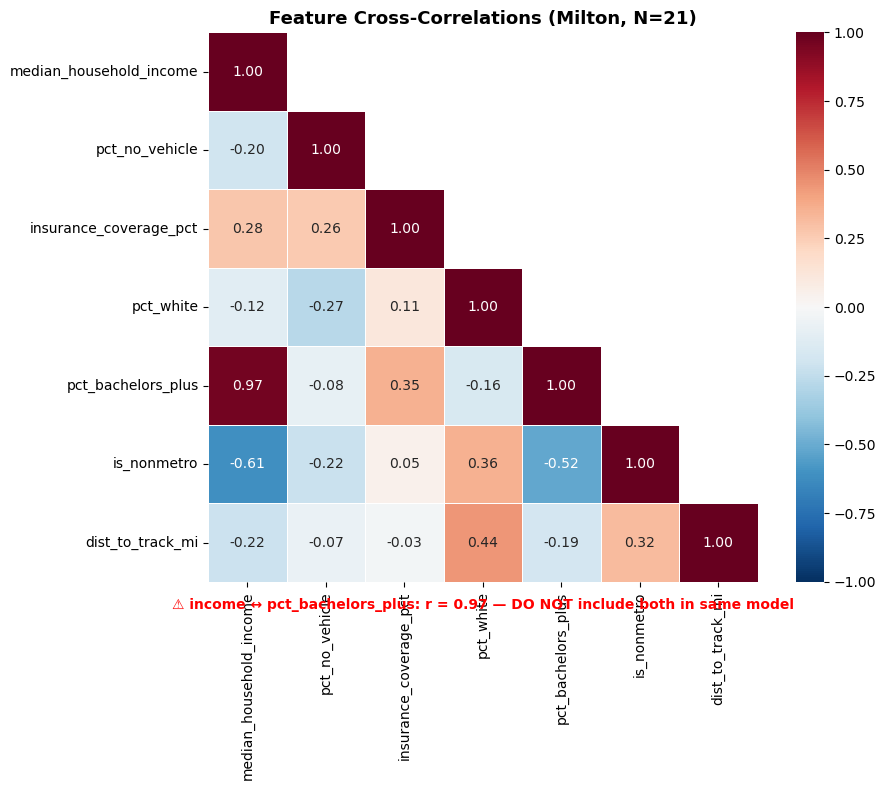


Variance Inflation Factors (VIF):
  VIF > 5 indicates problematic collinearity
  median_household_income        VIF = 3.01
  pct_no_vehicle                 VIF = 1.94
  insurance_coverage_pct         VIF = 1.72
  pct_white                      VIF = 1.47
  is_nonmetro                    VIF = 2.83
  dist_to_track_mi               VIF = 1.32


In [3]:
# ── Correlation heatmap of all candidate features ──
all_features = ['median_household_income', 'pct_no_vehicle', 'insurance_coverage_pct',
                'pct_white', 'pct_bachelors_plus', 'is_nonmetro', 'dist_to_track_mi']

corr = df[all_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            mask=mask)
ax.set_title('Feature Cross-Correlations (Milton, N=21)', fontsize=13, fontweight='bold')

# Highlight dangerous collinearity
ax.text(0.5, -0.05,
        '⚠ income ↔ pct_bachelors_plus: r = 0.97 — DO NOT include both in same model',
        transform=ax.transAxes, fontsize=10, ha='center', color='red', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'figures', 'correlation_heatmap.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
features_for_vif = ['median_household_income', 'pct_no_vehicle', 'insurance_coverage_pct',
                     'pct_white', 'is_nonmetro', 'dist_to_track_mi']
X_vif = df[features_for_vif].dropna()
scaler = StandardScaler()
X_vif_z = pd.DataFrame(scaler.fit_transform(X_vif), columns=features_for_vif)
X_vif_z = sm.add_constant(X_vif_z)

print('\nVariance Inflation Factors (VIF):')
print('  VIF > 5 indicates problematic collinearity')
for i, col in enumerate(X_vif_z.columns):
    if col == 'const':
        continue
    vif = variance_inflation_factor(X_vif_z.values, i)
    flag = ' ⚠' if vif > 5 else ''
    print(f'  {col:<30} VIF = {vif:.2f}{flag}')

## 3. OLS Models

Three model specifications (education excluded due to collinearity):
- **M1**: Income + Vehicle access + Insurance
- **M2**: M1 + Race (% White) + Urban-Rural (binary)
- **M3**: M2 + Distance to hurricane track

In [4]:
# ── Define DVs and model specs ──
DV_CONFIGS = {
    'largest_drop': {'col': 'largest_drop', 'label': 'Largest Drop — Within (%)', 'flip': False},
    'recovery_days': {'col': 'recovery_days', 'label': 'Recovery Time — Within (days)', 'flip': False},
    'largest_increase': {'col': 'largest_increase', 'label': 'Outflow Increase (%)', 'flip': False},
    'total_disruption': {'col': 'total_disruption', 'label': 'Total Disruption (days × %)', 'flip': False},
}

FEATURES_M1 = ['median_household_income', 'pct_no_vehicle', 'insurance_coverage_pct']
FEATURES_M2 = FEATURES_M1 + ['pct_white', 'is_nonmetro']
FEATURES_M3 = FEATURES_M2 + ['dist_to_track_mi']

MODEL_SPECS = {
    'M1': {'features': FEATURES_M1, 'label': 'Income + Vehicle + Insurance'},
    'M2': {'features': FEATURES_M2, 'label': 'M1 + Race + Urban-Rural'},
    'M3': {'features': FEATURES_M3, 'label': 'M2 + Distance'},
}

# ── Run all models ──
all_results = []
all_models = {}  # store fitted models

for dv_key, dv_cfg in DV_CONFIGS.items():
    for m_key, m_cfg in MODEL_SPECS.items():
        features = m_cfg['features']
        df_valid = df.dropna(subset=[dv_cfg['col']] + features)
        
        scaler = StandardScaler()
        X_z = pd.DataFrame(scaler.fit_transform(df_valid[features]),
                           columns=features, index=df_valid.index)
        X = sm.add_constant(X_z)
        y = df_valid[dv_cfg['col']]
        model = sm.OLS(y, X).fit()
        
        all_models[(dv_key, m_key)] = model
        
        row = {
            'DV': dv_cfg['label'],
            'Model': m_key,
            'Features': m_cfg['label'],
            'N': len(df_valid),
            'R²': model.rsquared,
            'Adj. R²': model.rsquared_adj,
            'F p-value': model.f_pvalue,
            'AIC': model.aic,
        }
        # Add coefficients
        for feat in features:
            row[f'{feat}_coef'] = model.params.get(feat, np.nan)
            row[f'{feat}_p'] = model.pvalues.get(feat, np.nan)
        
        all_results.append(row)

results_df = pd.DataFrame(all_results)
results_df.to_csv(os.path.join(OUTPUT_DIR, 'ols_model_comparison.csv'), index=False)
print('All models fitted. Results saved.')

All models fitted. Results saved.


## 4. Model Comparison Table

In [5]:
# ── Print model comparison ──
for dv_key, dv_cfg in DV_CONFIGS.items():
    print('\n' + '=' * 80)
    print(f'DV: {dv_cfg["label"]}')
    print('=' * 80)
    
    print(f'{"Model":<40} {"R²":>8} {"Adj.R²":>8} {"F p":>12} {"AIC":>8}')
    print('-' * 76)
    for m_key, m_cfg in MODEL_SPECS.items():
        model = all_models[(dv_key, m_key)]
        sig = '**' if model.f_pvalue < 0.05 else '*' if model.f_pvalue < 0.1 else ''
        print(f'{m_key}: {m_cfg["label"]:<36} {model.rsquared:>8.4f} {model.rsquared_adj:>8.4f} '
              f'{model.f_pvalue:>12.4e} {model.aic:>8.1f} {sig}')
    
    # Show best model coefficients
    best_m = 'M2'  # show M2 as primary model
    model = all_models[(dv_key, best_m)]
    print(f'\n  {best_m} Coefficients (standardized):')
    print(f'  {"Variable":<30} {"Coef":>8} {"Std Err":>8} {"p":>8} {"95% CI":>20}')
    print(f'  {"-"*74}')
    for var in model.params.index:
        if var == 'const':
            continue
        ci = model.conf_int().loc[var]
        sig = '**' if model.pvalues[var] < 0.05 else '*' if model.pvalues[var] < 0.1 else ''
        print(f'  {var:<30} {model.params[var]:>8.3f} {model.bse[var]:>8.3f} '
              f'{model.pvalues[var]:>8.4f} [{ci[0]:>7.3f}, {ci[1]:>7.3f}] {sig}')


DV: Largest Drop — Within (%)
Model                                          R²   Adj.R²          F p      AIC
----------------------------------------------------------------------------
M1: Income + Vehicle + Insurance           0.0262  -0.1457   9.2679e-01    144.7 
M2: M1 + Race + Urban-Rural                0.0615  -0.2514   9.5903e-01    147.9 
M3: M2 + Distance                          0.1087  -0.2733   9.3469e-01    148.8 

  M2 Coefficients (standardized):
  Variable                           Coef  Std Err        p               95% CI
  --------------------------------------------------------------------------
  median_household_income           1.015    2.755   0.7177 [ -4.857,   6.887] 
  pct_no_vehicle                   -0.757    2.202   0.7360 [ -5.451,   3.937] 
  insurance_coverage_pct           -0.265    2.072   0.9000 [ -4.681,   4.152] 
  pct_white                        -1.154    1.770   0.5245 [ -4.927,   2.620] 
  is_nonmetro                       1.233    2.644  

## 5. Coefficient Comparison Plot

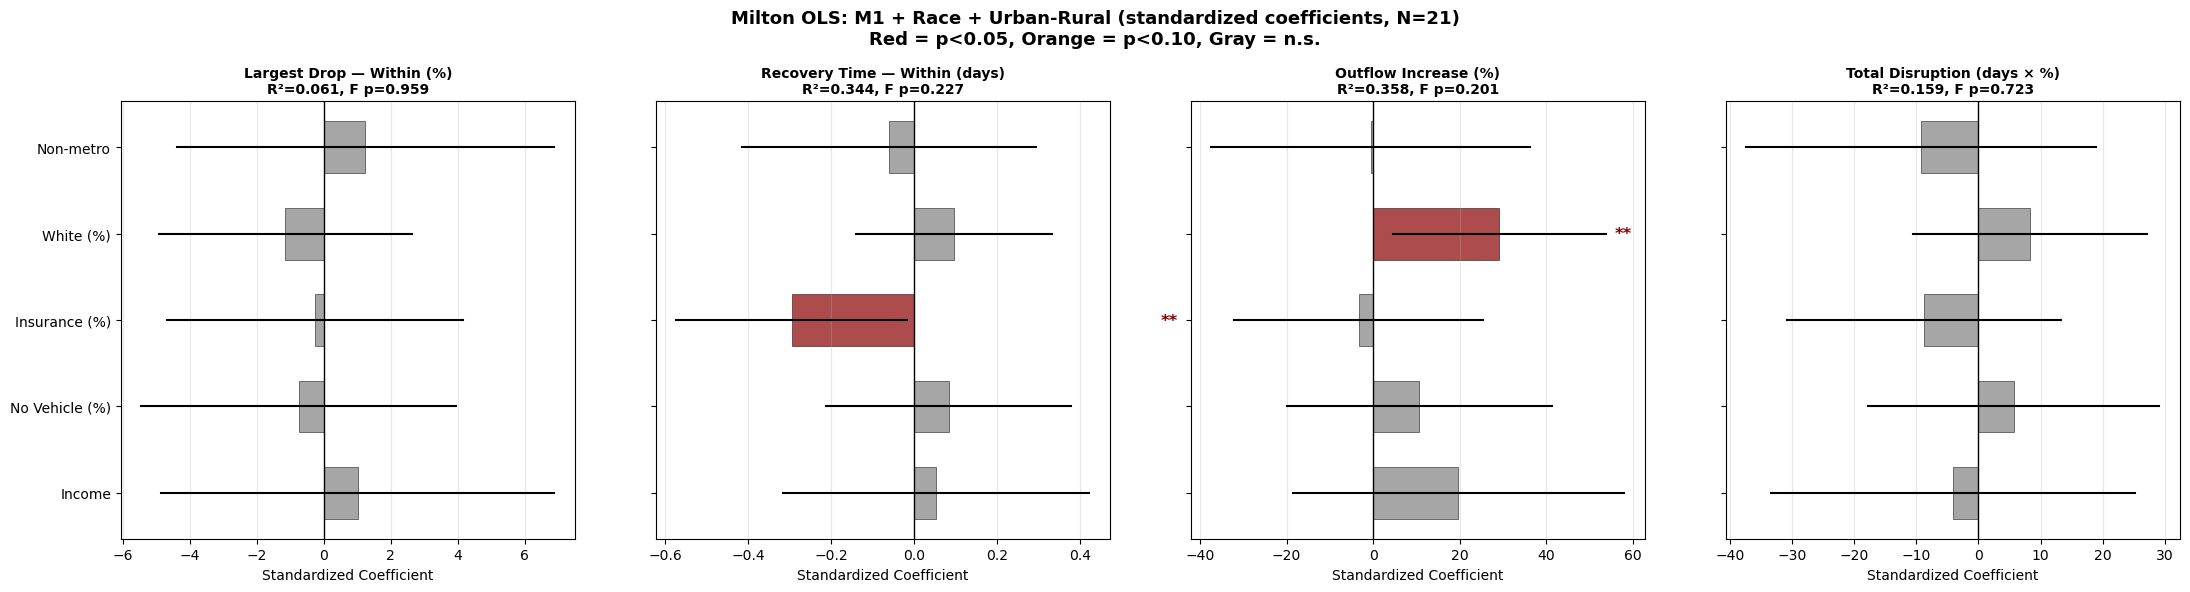

In [6]:
# ── Coefficient plot: M2 across all DVs ──
fig, axes = plt.subplots(1, 4, figsize=(22, 6), sharey=True)

m_key = 'M2'
features = MODEL_SPECS[m_key]['features']
feature_labels = {
    'median_household_income': 'Income',
    'pct_no_vehicle': 'No Vehicle (%)',
    'insurance_coverage_pct': 'Insurance (%)',
    'pct_white': 'White (%)',
    'is_nonmetro': 'Non-metro',
}

for ax, (dv_key, dv_cfg) in zip(axes, DV_CONFIGS.items()):
    model = all_models[(dv_key, m_key)]
    
    coefs = [model.params[f] for f in features]
    ci_low = [model.conf_int().loc[f][0] for f in features]
    ci_high = [model.conf_int().loc[f][1] for f in features]
    pvals = [model.pvalues[f] for f in features]
    
    y_pos = range(len(features))
    colors = ['darkred' if p < 0.05 else 'darkorange' if p < 0.1 else 'gray'
              for p in pvals]
    
    ax.barh(y_pos, coefs, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5, height=0.6)
    
    # Error bars
    for i, (c, lo, hi, p) in enumerate(zip(coefs, ci_low, ci_high, pvals)):
        ax.plot([lo, hi], [i, i], color='black', linewidth=1.5)
        sig = '**' if p < 0.05 else '*' if p < 0.1 else ''
        if sig:
            ax.text(max(abs(lo), abs(hi)) + 0.02 * (ax.get_xlim()[1] - ax.get_xlim()[0]),
                    i, sig, fontsize=12, fontweight='bold',
                    color='darkred' if p < 0.05 else 'darkorange', va='center')
    
    ax.axvline(0, color='black', linewidth=1, linestyle='-')
    ax.set_yticks(y_pos)
    ax.set_yticklabels([feature_labels.get(f, f) for f in features], fontsize=10)
    ax.set_xlabel('Standardized Coefficient', fontsize=10)
    ax.set_title(f'{dv_cfg["label"]}\nR²={model.rsquared:.3f}, F p={model.f_pvalue:.3f}',
                 fontsize=10, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

fig.suptitle(f'Milton OLS: {MODEL_SPECS[m_key]["label"]} (standardized coefficients, N=21)\n'
             'Red = p<0.05, Orange = p<0.10, Gray = n.s.',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'figures', 'coefficient_plot_M2.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 6. Bivariate Scatter Plots (Key Relationships)

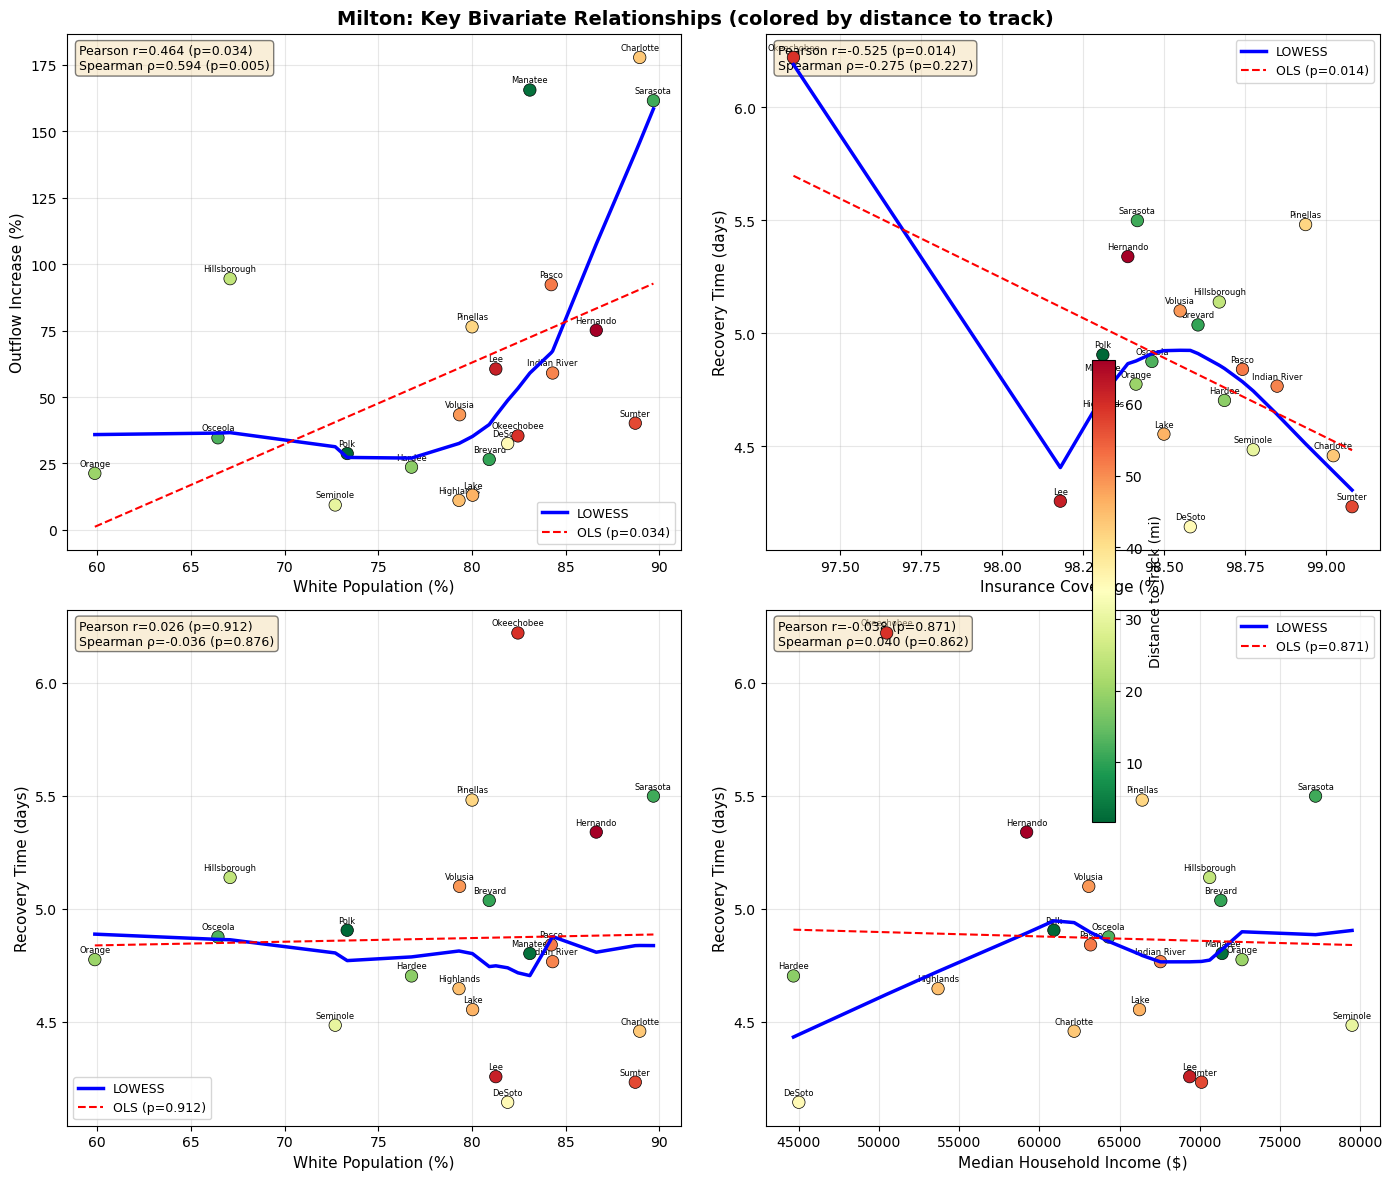

In [7]:
# ── Scatter plots for significant/marginal relationships ──
from statsmodels.nonparametric.smoothers_lowess import lowess as lowess_func

key_pairs = [
    ('pct_white', 'largest_increase', 'White Population (%)', 'Outflow Increase (%)'),
    ('insurance_coverage_pct', 'recovery_days', 'Insurance Coverage (%)', 'Recovery Time (days)'),
    ('pct_white', 'recovery_days', 'White Population (%)', 'Recovery Time (days)'),
    ('median_household_income', 'recovery_days', 'Median Household Income ($)', 'Recovery Time (days)'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, (x_col, y_col, x_label, y_label) in zip(axes.flat, key_pairs):
    valid = df[[x_col, y_col, 'NAME', 'dist_to_track_mi']].dropna()
    
    # Scatter colored by distance
    norm = plt.Normalize(valid['dist_to_track_mi'].min(), valid['dist_to_track_mi'].max())
    sc = ax.scatter(valid[x_col], valid[y_col],
                    c=valid['dist_to_track_mi'], cmap='RdYlGn_r', norm=norm,
                    s=80, edgecolors='black', linewidth=0.5, zorder=5)
    
    # LOWESS
    if len(valid) >= 5:
        lw = lowess_func(valid[y_col].values, valid[x_col].values, frac=0.6)
        ax.plot(lw[:, 0], lw[:, 1], color='blue', lw=2.5, label='LOWESS', zorder=10)
    
    # OLS line
    X_ols = sm.add_constant(valid[x_col])
    ols = sm.OLS(valid[y_col], X_ols).fit()
    x_range = np.linspace(valid[x_col].min(), valid[x_col].max(), 100)
    ax.plot(x_range, ols.params[0] + ols.params[1] * x_range,
            color='red', lw=1.5, linestyle='--', label=f'OLS (p={ols.pvalues[1]:.3f})', zorder=10)
    
    # Annotate counties
    for _, row in valid.iterrows():
        ax.annotate(row['NAME'], (row[x_col], row[y_col]),
                    fontsize=6, ha='center', va='bottom',
                    xytext=(0, 4), textcoords='offset points')
    
    # Correlation stats
    r_p, p_p = pearsonr(valid[x_col], valid[y_col])
    r_s, p_s = spearmanr(valid[x_col], valid[y_col])
    ax.text(0.02, 0.98,
            f'Pearson r={r_p:.3f} (p={p_p:.3f})\nSpearman ρ={r_s:.3f} (p={p_s:.3f})',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='wheat', alpha=0.5))
    
    ax.set_xlabel(x_label, fontsize=11)
    ax.set_ylabel(y_label, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.colorbar(sc, ax=axes, label='Distance to Track (mi)', shrink=0.5, pad=0.02)
fig.suptitle('Milton: Key Bivariate Relationships (colored by distance to track)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'figures', 'scatter_key_relationships.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 7. Full Bivariate Correlation Table

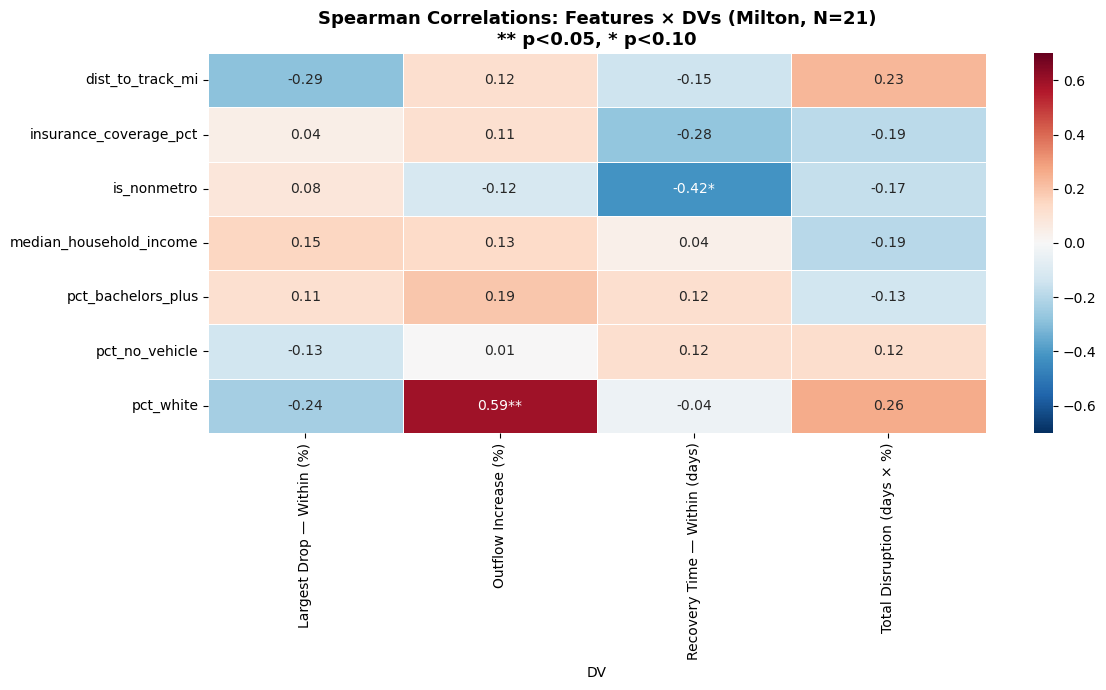


Significant bivariate correlations (p < 0.10):


,Feature,DV,Pearson r,Pearson p,Spearman ρ,Spearman p
9,insurance_coverage_pct,Recovery Time — Within (days),-0.525,0.014,-0.275,0.227
12,is_nonmetro,Recovery Time — Within (days),-0.193,0.401,-0.417,0.060
17,pct_white,Outflow Increase (%),0.464,0.034,0.594,0.005


In [8]:
# ── Bivariate correlations: all features × all DVs ──
features_all = ['median_household_income', 'pct_no_vehicle', 'insurance_coverage_pct',
                'pct_white', 'pct_bachelors_plus', 'is_nonmetro', 'dist_to_track_mi']

bivar_rows = []
for dv_key, dv_cfg in DV_CONFIGS.items():
    for feat in features_all:
        valid = df[[feat, dv_cfg['col']]].dropna()
        if len(valid) < 5:
            continue
        r_p, p_p = pearsonr(valid[feat], valid[dv_cfg['col']])
        r_s, p_s = spearmanr(valid[feat], valid[dv_cfg['col']])
        bivar_rows.append({
            'Feature': feat,
            'DV': dv_cfg['label'],
            'Pearson r': r_p,
            'Pearson p': p_p,
            'Spearman ρ': r_s,
            'Spearman p': p_s,
        })

bivar_df = pd.DataFrame(bivar_rows)

# Heatmap of Spearman correlations
pivot = bivar_df.pivot(index='Feature', columns='DV', values='Spearman ρ')
pivot_p = bivar_df.pivot(index='Feature', columns='DV', values='Spearman p')

# Create annotation with significance stars
annot = pivot.copy()
for feat in annot.index:
    for dv in annot.columns:
        r = pivot.loc[feat, dv]
        p = pivot_p.loc[feat, dv]
        star = '**' if p < 0.05 else '*' if p < 0.1 else ''
        annot.loc[feat, dv] = f'{r:.2f}{star}'

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(pivot.astype(float), annot=annot, fmt='', cmap='RdBu_r', center=0,
            vmin=-0.7, vmax=0.7, linewidths=0.5, ax=ax,
            annot_kws={'fontsize': 10})
ax.set_title('Spearman Correlations: Features × DVs (Milton, N=21)\n** p<0.05, * p<0.10',
             fontsize=13, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'figures', 'heatmap_bivariate.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Print table
print('\nSignificant bivariate correlations (p < 0.10):')
sig = bivar_df[(bivar_df['Spearman p'] < 0.10) | (bivar_df['Pearson p'] < 0.10)]
if len(sig) > 0:
    display(sig.round(3))
else:
    print('  None')

bivar_df.to_csv(os.path.join(OUTPUT_DIR, 'bivariate_correlations.csv'), index=False)

## 8. Sensitivity: With vs Without Okeechobee

In [9]:
# ── Check influence of Okeechobee on key results ──
print('Okeechobee sensitivity check (M2 model):')
print('=' * 80)

for dv_key, dv_cfg in DV_CONFIGS.items():
    features = FEATURES_M2
    
    # With all
    df_all = df.dropna(subset=[dv_cfg['col']] + features)
    scaler = StandardScaler()
    X_all = sm.add_constant(pd.DataFrame(scaler.fit_transform(df_all[features]),
                                          columns=features, index=df_all.index))
    m_all = sm.OLS(df_all[dv_cfg['col']], X_all).fit()
    
    # Without Okeechobee
    df_no_ok = df_all[df_all['GEOID'] != 12093]
    scaler2 = StandardScaler()
    X_no_ok = sm.add_constant(pd.DataFrame(scaler2.fit_transform(df_no_ok[features]),
                                            columns=features, index=df_no_ok.index))
    m_no_ok = sm.OLS(df_no_ok[dv_cfg['col']], X_no_ok).fit()
    
    print(f'\n{dv_cfg["label"]}:')
    print(f'  {"":<30} {"All (N=21)":>15} {"No Okeechobee":>15} {"Δ":>8}')
    print(f'  {"R²":<30} {m_all.rsquared:>15.4f} {m_no_ok.rsquared:>15.4f} '
          f'{m_no_ok.rsquared - m_all.rsquared:>8.4f}')
    print(f'  {"F p-value":<30} {m_all.f_pvalue:>15.4e} {m_no_ok.f_pvalue:>15.4e}')
    
    # Compare significant coefficients
    for feat in features:
        p1 = m_all.pvalues[feat]
        p2 = m_no_ok.pvalues[feat]
        if p1 < 0.1 or p2 < 0.1:
            s1 = '**' if p1 < 0.05 else '*' if p1 < 0.1 else ''
            s2 = '**' if p2 < 0.05 else '*' if p2 < 0.1 else ''
            print(f'  {feat:<30} p={p1:.4f} {s1:<3} → p={p2:.4f} {s2:<3} '
                  f'(coef: {m_all.params[feat]:.3f} → {m_no_ok.params[feat]:.3f})')

Okeechobee sensitivity check (M2 model):

Largest Drop — Within (%):
                                      All (N=21)   No Okeechobee        Δ
  R²                                      0.0615          0.0883   0.0269
  F p-value                           9.5903e-01      9.2131e-01

Recovery Time — Within (days):
                                      All (N=21)   No Okeechobee        Δ
  R²                                      0.3441          0.4357   0.0916
  F p-value                           2.2706e-01      1.1745e-01
  insurance_coverage_pct         p=0.0388 **  → p=0.6569     (coef: -0.295 → 0.044)

Outflow Increase (%):
                                      All (N=21)   No Okeechobee        Δ
  R²                                      0.3582          0.3499  -0.0083
  F p-value                           2.0134e-01      2.4991e-01
  pct_white                      p=0.0237 **  → p=0.0292 **  (coef: 29.073 → 29.648)

Total Disruption (days × %):
                                      

## 9. Summary

### Key Findings for Milton (N=21)

1. **Outflow increase**: `pct_white` is the only robust predictor (Spearman ρ≈0.59, p=0.005).
   Whiter (more rural) counties had larger evacuation surges.

2. **Recovery time**: `insurance_coverage_pct` is significant in M1/M2 but sensitive to Okeechobee.
   `is_nonmetro` shows marginal negative association (non-metro counties recover slightly faster).

3. **Largest drop & total disruption**: No significant predictors. Disruption magnitude is
   essentially independent of socioeconomic characteristics.

4. **Collinearity warning**: Income and education (r=0.97) cannot be in the same model.
   Any "education effect" is indistinguishable from income.

5. **Small N caveat**: With 21 observations, all results are sensitive to individual counties.
   The Okeechobee sensitivity analysis shows coefficients can flip with a single removal.